# Non-Autonomous Terms and VF-b Test
This notebook uses the best candidates from SINDy_FHN.ipynb for fitting data.  These include the following options:
* Model - VF-b (most realistic FHN model)
* Optimizer - SSR
* feature_library - degree 3 polynomials

In [1]:
import math
import numpy as np
from scipy.integrate import odeint
from itertools import combinations_with_replacement
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook"
import pandas as pd
import importlib
import SINDy
importlib.reload(SINDy)

import pysindy as ps

In [2]:
# The old, non-truncated autonomous term (can be a problem for large exponents).
# Params:
#   t (1d array): Time input vector
def smooth_non_aut_old(t):
    return 1. / (1. + np.exp((25*np.sin(0.02*t))**2))

# A differentiable non-autonomous term truncated from the Taylor series of the above term.
# Params:
#   t (1d array): Time input vector
def smooth_non_aut(t):
    return 1. / (2. + (200*np.sin(0.02*t))**4)

# TODO
# Logical step function non-autonomous term.
# Params:
#   t (1d array): Time input vector
#
def logical_non_aut(t):
    return 0.5 * (np.sin(0.02*t) < 0.1) * (np.sin(0.02*t) > -0.1)

'''
Generate the data using the VF-b modified FHN equations:
Params:
    state (2d array):        Contains the state variables u and v
    t (1d array):            Time input
    non_aut_term (1d array): A non-autonomous term to be added to the u_dot equation
    alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 1.0, eps = 0.005, theta = -0.05, mu = 1.0 (Old auto-oscillatory parameters used to get these equations)
'''
def fhn_vf_b(state, t, non_aut_term, alpha = 0.2, beta = 1.1, gamma = 0.31, delta = 0.0, eps = 0.005, theta = -0.05, mu = 1.0):
    u, v = state
    u_dot = mu*u*(1 - u)*(u - alpha) - u*v # Note - version w/out unrealistic hyperpolarization has -u*v instead of -v. However, only get full domain with -v (why?)
    v_dot = eps*((beta - u)*(u - gamma) - delta*v - theta)

    # Add time-dependent voltage perturbation
    u_dot +=  non_aut_term(t)
    return u_dot, v_dot

# Time step and initial values; seems like 0-600 is minimum timeframe needed to identify dynamics
dt = 0.01
t_vf_b = np.arange(0,2000,dt)   # Note: t around 3000 and above causes tab to crash
x_0_vf_b = np.array([0.5,0])
states_vf_b = odeint(fhn_vf_b, x_0_vf_b, t_vf_b, args=(logical_non_aut,)) # Test code --> lambda t: 0         Actual code --> logical_non_aut

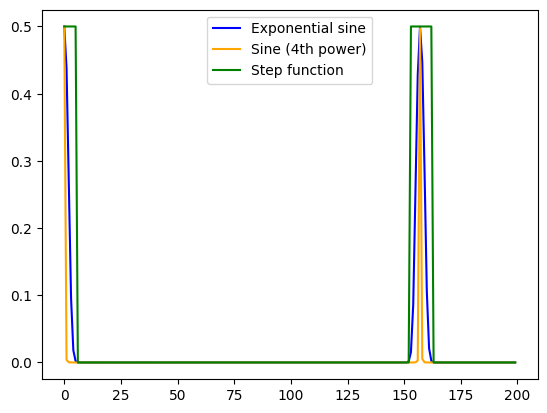

In [3]:
# Compare the forcing functions. Note that we can't actually use the exponential since it will encounter overflow for the peak tightness
# that we need; instead, take part of the Taylor series, then throw out the terms we don't need while still maintaing a representative shape.
t = np.array(range(0,200))
plt.plot(t, smooth_non_aut_old(t), color = 'blue', label='Exponential sine')
plt.plot(t, smooth_non_aut(t), color='orange', label='Sine (4th power)')
plt.plot(t, logical_non_aut(t), color='green', label='Step function')
plt.legend()

Now, let's try fitting the above with some non-autonomous terms included:

In [4]:
# Run SINDy on VF-FHN w/ time-varying terms.
# Note: There are some extraneous terms hiding around precision = 6-10 that show up, but they shouldn't affect the solution much.
# TODO How to remove these terms?
opt_vf_b = ps.SSR(alpha=0.00001)
model_vf_b = ps.SINDy(feature_names=["u", "v"], feature_library=ps.PolynomialLibrary(degree=3), optimizer=opt_vf_b)
model_vf_b.fit(states_vf_b, t=t_vf_b)
model_vf_b.print(precision=5)

(u)' = 0.00798 1 + 1.60744 u + -0.05223 v + -2.44193 u^2 + -6.62779 u v + -0.32830 v^2 + 0.84218 u^3 + 6.10133 u^2 v + 2.05152 u v^2 + -0.33769 v^3
(v)' = -0.00145 1 + 0.00705 u + -0.00500 u^2


Actual equations for comparison (without auto-oscillatory term $\delta$):

\begin{align}
    \dot{u} = - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} = -0.001455 + 0.00705u - 0.005u^2 \\
\end{align}

And with $\delta=1.0$:

\begin{align}
    \dot{u} = - 0.2 u + 1.2 u^2 - u v - 1 u^3 \\
    \dot{v} = -0.001455 + 0.00705u - 0.005u^2 - 0.005v \\
\end{align}

Text(0.5, 1.0, 'Values of u vs. v')

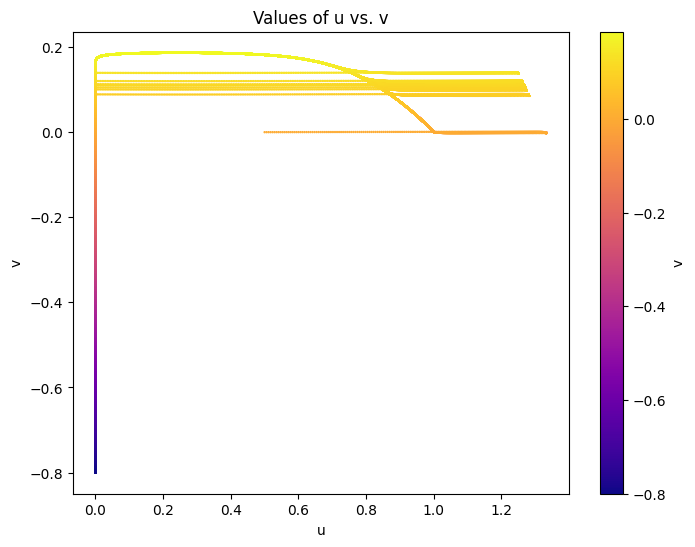

In [ ]:
# Plot results - u vs. v
df_states_vf_b = pd.DataFrame(states_vf_b, columns=['u','v'])

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    df_states_vf_b['u'], 
    df_states_vf_b['v'], 
    c=df_states_vf_b['v'],  # Color by 'v' column
    s=0.5,  # Marker size
    cmap='plasma'  # Optional: Choose a colormap similar to Plotly's default
)

# Add colorbar for the 'v' values
plt.colorbar(scatter, label='v')
plt.xlabel('u')
plt.ylabel('v')
plt.title('Values of u vs. v')

[0.5, 0.5057571300076548, 0.5115284240152824, 0.5173136961852672, 0.5231127660621447, 0.5289253924260904, 0.5347513576226868, 0.5405904267138427, 0.546442338522658, 0.5523068388691512]
[0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09]


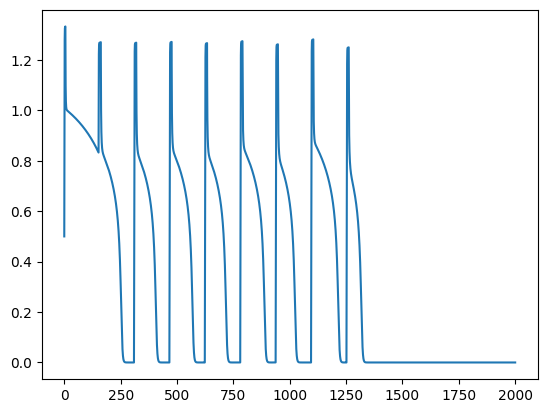

In [6]:
# Plot result - time domain - u vs. t
u_vf_b = df_states_vf_b['u'].tolist()
print(u_vf_b[0:10])
print(t_vf_b[0:10])

plt.plot(t_vf_b,u_vf_b)